Multivariate ML forecasting using engineered time-series features

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os

In [2]:
DATA_PATH = "2017 Monthly Bike Count Totals for East River Bridges"

In [3]:
def load_data():
    dfs = []

    for f in os.listdir(DATA_PATH):
        if f.endswith(".xlsx"):

            df = pd.read_excel(
                os.path.join(DATA_PATH, f),
                header=5,
                usecols="B:K"
            )

            df.columns = df.columns.str.lower()
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df = df[df["date"].notna()]

            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    df = df.melt(
        id_vars=['date', 'high temp (°f)', 'low temp (°f)', 'precipitation'], 
        value_vars=['brooklyn bridge', 'manhattan bridge', 'williamsburg bridge', 'queensboro bridge'],
        var_name='bridge',
        value_name='count'
    )

    df['precipitation'] = df['precipitation'].replace('T', 0.005)

    df = df.sort_values("date")
    df = df.reset_index(drop=True)

    return df

In [4]:
df = load_data()
df

,date,high temp (°f),low temp (°f),precipitation,bridge,count
0,2017-04-01,46.0,37,0,williamsburg bridge,1915.0
1,2017-04-01,46.0,37,0,brooklyn bridge,606.0
2,2017-04-01,46.0,37,0,queensboro bridge,1430.0
3,2017-04-01,46.0,37,0,manhattan bridge,1446
4,2017-04-02,62.1,41,0,queensboro bridge,2862.0
...,...,...,...,...,...,...
851,2017-10-30,55.0,46,0.25,manhattan bridge,2966
852,2017-10-31,54.0,44,0,williamsburg bridge,5894.0
853,2017-10-31,54.0,44,0,queensboro bridge,4883.0
854,2017-10-31,54.0,44,0,manhattan bridge,5597


In [5]:
df["dayofweek"] = df["date"].dt.dayofweek
df["day"] = df["date"].dt.day

In [6]:
df["lag1"] = df.groupby("bridge")["count"].shift(1)
df["lag7"] = df.groupby("bridge")["count"].shift(7)

In [7]:
df["roll7"] = df.groupby("bridge")["count"].rolling(7).mean().reset_index(level=0, drop=True)
df["roll30"] = df.groupby("bridge")["count"].rolling(30).mean().reset_index(level=0, drop=True)

In [8]:
df

,date,high temp (°f),low temp (°f),precipitation,bridge,count,dayofweek,day,lag1,lag7,roll7,roll30
0,2017-04-01,46.0,37,0,williamsburg bridge,1915.0,5,1,NaN,NaN,NaN,NaN
1,2017-04-01,46.0,37,0,brooklyn bridge,606.0,5,1,NaN,NaN,NaN,NaN
2,2017-04-01,46.0,37,0,queensboro bridge,1430.0,5,1,NaN,NaN,NaN,NaN
3,2017-04-01,46.0,37,0,manhattan bridge,1446,5,1,NaN,NaN,NaN,NaN
4,2017-04-02,62.1,41,0,queensboro bridge,2862.0,6,2,1430.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
851,2017-10-30,55.0,46,0.25,manhattan bridge,2966,0,30,661,6671,4044.000000,5287.733333
852,2017-10-31,54.0,44,0,williamsburg bridge,5894.0,1,31,3547.0,3251.0,5039.000000,6026.700000
853,2017-10-31,54.0,44,0,queensboro bridge,4883.0,1,31,2924.0,2682.0,4127.000000,4795.966667
854,2017-10-31,54.0,44,0,manhattan bridge,5597,1,31,2966,2614,4470.142857,5322.966667


In [9]:
bridge_encoder = OrdinalEncoder()
df["bridge"] = bridge_encoder.fit_transform(df[["bridge"]])

In [10]:
def train_test_split(df, test_size=0.3):
    split = int(len(df) * (1 - test_size))
    return df.iloc[:split], df.iloc[split:]

In [11]:
train, test = train_test_split(df)

In [12]:
feature_cols = [c for c in df.columns if c not in ["date", "count"]]

In [13]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [14]:
X_train = train[feature_cols]
y_train = train["count"]

X_test = test[feature_cols]
y_test = test["count"]

In [15]:
feature_cols

['high temp (°f)',
 'low temp (°f)',
 'precipitation',
 'bridge',
 'dayofweek',
 'day',
 'lag1',
 'lag7',
 'roll7',
 'roll30']

In [16]:
model = HistGradientBoostingRegressor(categorical_features=[0, 0, 0, 1, 1, 1, 0, 0, 0, 0])

In [17]:
model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 

In [18]:
preds = model.predict(X_test)

In [19]:
mae, rmse = evaluate(y_test, preds)

In [20]:
test["preds"] = preds
test["y_test"] = y_test

In [21]:
test

,date,high temp (°f),low temp (°f),precipitation,bridge,count,dayofweek,day,lag1,lag7,roll7,roll30,preds,y_test
599,2017-08-28,75.0,63,0,2.0,5917.0,0,28,4159.0,5666.0,5534.000000,5166.466667,6244.647297,5917.0
600,2017-08-29,68.0,62.1,0.1,0.0,1472.0,1,29,3332.0,2983.0,2859.428571,3056.266667,2770.256652,1472.0
601,2017-08-29,68.0,62.1,0.1,3.0,3776.0,1,29,7343.0,7146.0,6323.571429,6365.500000,5558.419261,3776.0
602,2017-08-29,68.0,62.1,0.1,2.0,3563.0,1,29,5917.0,5795.0,5215.142857,5141.100000,4592.092475,3563.0
603,2017-08-29,68.0,62.1,0.1,1.0,3206,1,29,6908,6151,5633.428571,5706.166667,5375.083770,3206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,2017-10-30,55.0,46,0.25,1.0,2966,0,30,661,6671,4044.000000,5287.733333,3627.246195,2966
852,2017-10-31,54.0,44,0,3.0,5894.0,1,31,3547.0,3251.0,5039.000000,6026.700000,6549.847464,5894.0
853,2017-10-31,54.0,44,0,2.0,4883.0,1,31,2924.0,2682.0,4127.000000,4795.966667,4675.203925,4883.0
854,2017-10-31,54.0,44,0,1.0,5597,1,31,2966,2614,4470.142857,5322.966667,5950.570798,5597


In [22]:
print(f"\n=== HistGradientBoosting (Multivariate) ===")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")


=== HistGradientBoosting (Multivariate) ===
MAE: 601.82, RMSE: 844.28


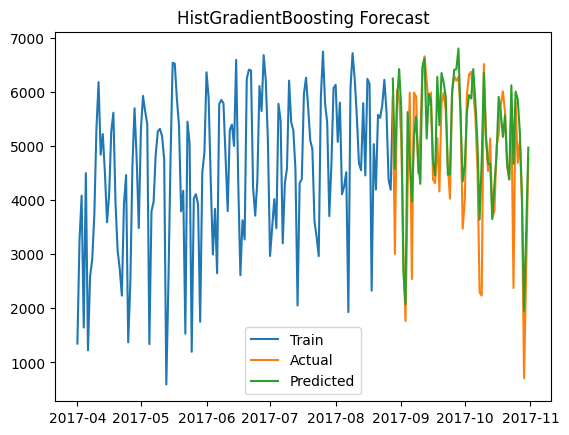

In [23]:
plt.figure()
plt.plot(train.groupby("date").mean().index, train.groupby("date").mean()["count"], label="Train")
plt.plot(test.groupby("date").mean().index, test.groupby("date").mean()["y_test"], label="Actual")
plt.plot(test.groupby("date").mean().index, test.groupby("date").mean()["preds"], label="Predicted")
plt.title(f"HistGradientBoosting Forecast")
plt.legend()
plt.show()

In [24]:
categories = bridge_encoder.categories_[0]
inverse_dict = {float(index): category for index, category in enumerate(categories)}

Running ML model for williamsburg bridge


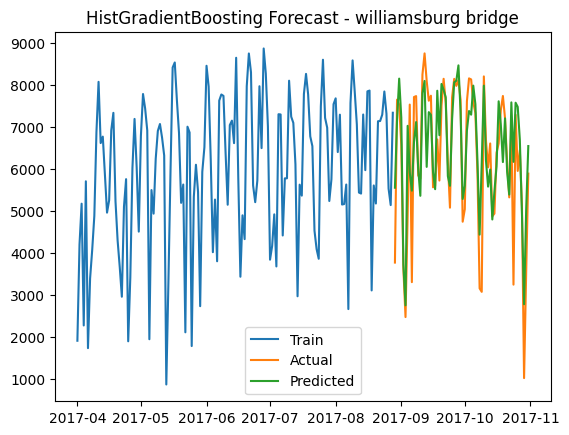

MAE: 717.68, RMSE: 989.34
Running ML model for brooklyn bridge


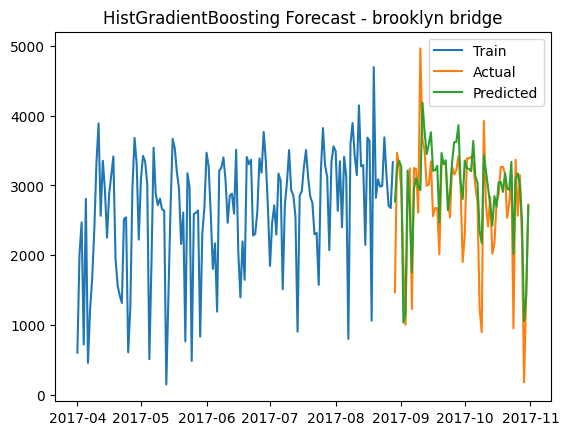

MAE: 421.97, RMSE: 561.25
Running ML model for queensboro bridge


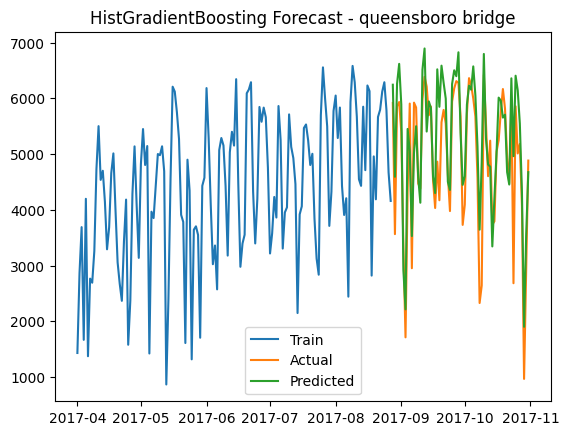

MAE: 542.35, RMSE: 716.49
Running ML model for manhattan bridge


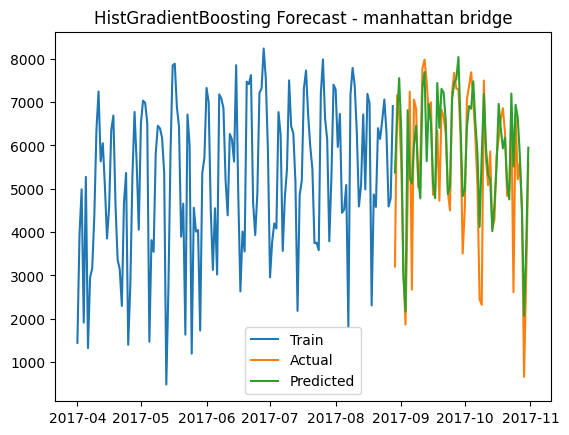

MAE: 726.19, RMSE: 1023.33


In [25]:
for bridge in df["bridge"].unique():
    print(f"Running ML model for {inverse_dict[bridge]}")
    train_subset = train[train["bridge"] == bridge]
    test_subset = test[test["bridge"] == bridge]
    plt.figure()
    plt.plot(train_subset.groupby("date").mean().index, train_subset.groupby("date").mean()["count"], label="Train")
    plt.plot(test_subset.groupby("date").mean().index, test_subset.groupby("date").mean()["y_test"], label="Actual")
    plt.plot(test_subset.groupby("date").mean().index, test_subset.groupby("date").mean()["preds"], label="Predicted")
    plt.title(f"HistGradientBoosting Forecast - {inverse_dict[bridge]}")
    plt.legend()
    plt.show()

    mae, rmse = evaluate(test_subset["y_test"].values, test_subset["preds"].values)
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")